In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from asrl.slam.icp import icp
import matplotlib.pyplot as plt
from spatialmath import SO2, SE2
from asrl.slam.icp2d import ICP2d
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [9]:
def xyt_from_planar_SE3(T):
    """
    Convert a flat SE(3) matrix to an SE(2) matrix.
    """
    return SE2(T[0, 3], T[1, 3], np.arctan2(T[1, 0], T[0, 0]))

def sample_square_edges(side_length, N):
    """
    Sample N points uniformly at random along the edges of a square.
    """
    perim = 4 * side_length
    t = np.random.rand(N) * perim

    x = np.zeros(N)
    y = np.zeros(N)
    L = side_length

    # Bottom edge (0 to L)
    mask = t < L
    x[mask] = t[mask]
    y[mask] = 0

    # Right edge (L to 2L)
    mask = (t >= L) & (t < 2*L)
    x[mask] = L
    y[mask] = t[mask] - L

    # Top edge (2L to 3L)
    mask = (t >= 2*L) & (t < 3*L)
    x[mask] = L - (t[mask] - 2*L)
    y[mask] = L

    # Left edge (3L to 4L)
    mask = t >= 3*L
    x[mask] = 0
    y[mask] = L - (t[mask] - 3*L)

    return np.vstack([x, y]).T - side_length / 2

def sample_circle_edges(radius, N):
    """
    Sample N points uniformly at random along the edges of a circle.
    """
    angles = np.random.rand(N) * 2 * np.pi
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    return np.vstack([x, y]).T

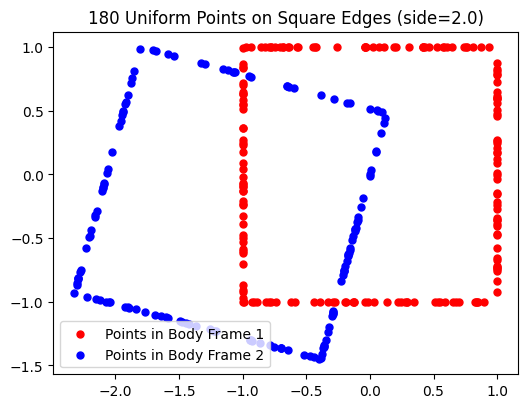

In [18]:
# Parameters
side_length = 2.0
N = 180

# Generate and plot
points_W_1 = sample_square_edges(side_length, int(N * 1.0))
points_W_2 = sample_square_edges(side_length, int(N * 0.8))
# points_W_2 = sample_circle_edges(side_length / 2, int(N * 0.8))

W_T_R_1 = SE2(0.0, 0.0, 0.0)
W_T_R_2 = SE2(1.0, 0.5, 15.0, unit='deg')

points_B_1 = (W_T_R_1.inv() * points_W_1.T)
points_B_2 = (W_T_R_2.inv() * points_W_2.T)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(points_B_1[0, :], points_B_1[1, :], c='r', s=25, label='Points in Body Frame 1')
ax.scatter(points_B_2[0, :], points_B_2[1, :], c='b', s=25, label='Points in Body Frame 2')

ax.set_aspect('equal', 'box')
ax.set_title(f'{N} Uniform Points on Square Edges (side={side_length})')
ax.legend()
plt.show()

In [19]:
(R, t), result = ICP2d(points_B_2.T, points_B_1.T, max_corr_dist=1.0)
print(R, t)
print(result.fitness)
print(result.inlier_rmse)

[[ 0.97061794 -0.24062588]
 [ 0.24062588  0.97061794]] [1.0053333  0.47751197]
1.0
0.029498400654444378


In [20]:
re_points_W_2 = R @ points_B_2 + t[:, None]

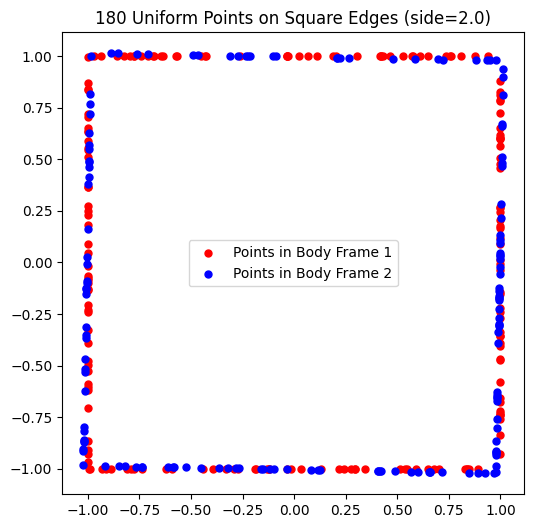

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(points_B_1[0, :], points_B_1[1, :], c='r', s=25, label='Points in Body Frame 1')
ax.scatter(re_points_W_2[0, :], re_points_W_2[1, :], c='b', s=25, label='Points in Body Frame 2')

ax.set_aspect('equal', 'box')
ax.set_title(f'{N} Uniform Points on Square Edges (side={side_length})')
ax.legend()
plt.show()